# Primer Parcial - Machine Learning 1
## Modelado

### Objetivo

El objetivo de esta etapa es construir modelos de clasificación que permitan
estimar la probabilidad de que un estudiante de Métodos Numéricos alcance una
firma final de 71 puntos o más.

Se compararán dos enfoques:

- **Modelo base:** utiliza únicamente el puntaje del primer parcial.
- **Modelo completo:** incorpora además información sobre firma previa, carga
  académica, rendimiento del ciclo anterior y carrera.

La comparación permitirá evaluar si el historial académico aporta información
adicional más allá del rendimiento observado en el primer parcial.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. Carga del dataset

Se utiliza el dataset preparado durante la etapa de preprocesamiento, que
contiene las variables seleccionadas para el análisis y la variable objetivo
`exonera`.

In [2]:
ruta = "../data/dataset_metodos_numericos_modelo.csv"

df = pd.read_csv(ruta)

df.head()

,carrera,primer_parcial,firma_previa,cantidad_materias_actual,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,exonera
0,Ing. Geográfica,0,40,7,5,1,0.200000,0
1,Ing. Geográfica,0,40,7,5,1,0.200000,0
2,Ing. Industrial,0,53,7,7,3,0.428571,0
3,Ing. Industrial,0,53,7,7,3,0.428571,0
4,Ing. Civil,0,34,6,6,4,0.666667,0


In [3]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (260, 8)
<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   carrera                      260 non-null    str    
 1   primer_parcial               260 non-null    int64  
 2   firma_previa                 260 non-null    int64  
 3   cantidad_materias_actual     260 non-null    int64  
 4   cantidad_materias_anterior   260 non-null    int64  
 5   materias_aprobadas_anterior  260 non-null    int64  
 6   tasa_aprobacion_anterior     260 non-null    float64
 7   exonera                      260 non-null    int64  
dtypes: float64(1), int64(6), str(1)
memory usage: 16.4 KB


## 3. Definición de la variable objetivo

La variable objetivo es `exonera`:

- `1`: el estudiante alcanza una firma final mayor o igual a 71.
- `0`: el estudiante no alcanza dicho umbral.

In [4]:
y = df["exonera"]

print(y.value_counts())
print()
print((y.value_counts(normalize=True) * 100).round(2))

exonera
0    226
1     34
Name: count, dtype: int64

exonera
0    86.92
1    13.08
Name: proportion, dtype: float64


## 4. División entre entrenamiento y prueba

El dataset se divide en conjuntos de entrenamiento y prueba.

Se utiliza una división estratificada para conservar aproximadamente la misma
proporción de estudiantes que exoneran y no exoneran en ambos conjuntos.

In [5]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", len(train_idx))
print("Prueba:", len(test_idx))

Entrenamiento: 195
Prueba: 65


In [6]:
print("Distribución en entrenamiento:")
print(df.loc[train_idx, "exonera"].value_counts(normalize=True).round(3))

print("\nDistribución en prueba:")
print(df.loc[test_idx, "exonera"].value_counts(normalize=True).round(3))

Distribución en entrenamiento:
exonera
0    0.867
1    0.133
Name: proportion, dtype: float64

Distribución en prueba:
exonera
0    0.877
1    0.123
Name: proportion, dtype: float64


## 5. Función de evaluación

Se define una función para calcular las principales métricas de clasificación.

Dado que la variable objetivo está desbalanceada, no se utiliza únicamente
`accuracy`. También se consideran `precision`, `recall`, `F1-score` y `ROC-AUC`.

In [7]:
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    return resultados, y_pred, y_prob

## 6. Modelo base: primer parcial

Como referencia inicial se entrena una Regresión Logística utilizando únicamente
el puntaje del primer parcial.

Este modelo permitirá medir cuánto poder predictivo aporta por sí solo el
rendimiento académico observado hasta ese momento.

In [8]:
variables_base = ["primer_parcial"]

X_base = df[variables_base]

X_train_base = X_base.loc[train_idx]
X_test_base = X_base.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [9]:
modelo_base = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(random_state=42))
    ]
)

In [10]:
modelo_base.fit(X_train_base, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['primer_parcial']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [11]:
resultados_base, y_pred_base, y_prob_base = evaluar_modelo(
    modelo_base,
    X_test_base,
    y_test
)

pd.Series(resultados_base).round(3)

accuracy     0.908
precision    0.600
recall       0.750
f1           0.667
roc_auc      0.971
dtype: float64

### Matriz de confusión del modelo base

La matriz de confusión permite observar cuántos estudiantes fueron clasificados
correctamente y qué tipos de errores comete el modelo.

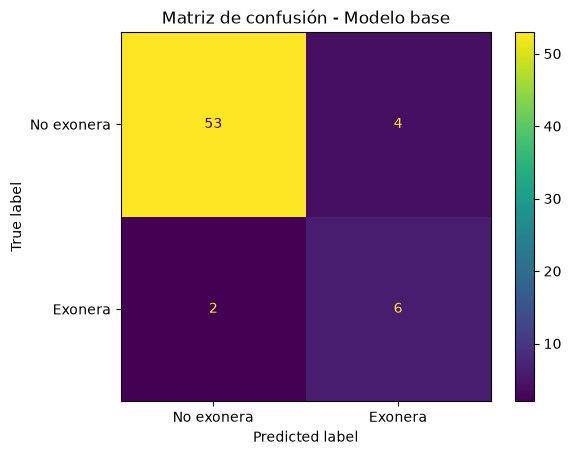

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base,
    display_labels=["No exonera", "Exonera"]
)

plt.title("Matriz de confusión - Modelo base")
plt.show()

In [13]:
print(
    classification_report(
        y_test,
        y_pred_base,
        target_names=["No exonera", "Exonera"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No exonera       0.96      0.93      0.95        57
     Exonera       0.60      0.75      0.67         8

    accuracy                           0.91        65
   macro avg       0.78      0.84      0.81        65
weighted avg       0.92      0.91      0.91        65



## 7. Modelo completo

El segundo modelo incorpora información adicional disponible hasta el momento
posterior al primer parcial.

Se utilizan:

- primer parcial;
- firma previa;
- cantidad de materias actuales;
- cantidad de materias del ciclo anterior;
- tasa de aprobación del ciclo anterior;
- carrera.

La variable `materias_aprobadas_anterior` no se incluye inicialmente debido a
su alta correlación con `tasa_aprobacion_anterior`.

In [14]:
variables_completas = [
    "primer_parcial",
    "firma_previa",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior",
    "carrera"
]

X_completo = df[variables_completas]

X_train_completo = X_completo.loc[train_idx]
X_test_completo = X_completo.loc[test_idx]

In [15]:
variables_numericas = [
    "primer_parcial",
    "firma_previa",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior"
]

variables_categoricas = [
    "carrera"
]

In [16]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            variables_numericas
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            variables_categoricas
        )
    ]
)

In [17]:
modelo_completo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LogisticRegression(random_state=42))
    ]
)

In [18]:
modelo_completo.fit(
    X_train_completo,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['primer_parcial','firma_previa','cantidad_materias_actual', 'cantidad_materias_anterior','tasa_aprobacion_anterior','carrera']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of 

In [19]:
resultados_completo, y_pred_completo, y_prob_completo = evaluar_modelo(
    modelo_completo,
    X_test_completo,
    y_test
)

pd.Series(resultados_completo).round(3)

accuracy     0.969
precision    0.875
recall       0.875
f1           0.875
roc_auc      0.974
dtype: float64

## 8. Comparación de modelos

Se comparan las métricas del modelo base y del modelo completo para determinar
si las variables históricas y académicas adicionales mejoran la capacidad de
predicción respecto al uso exclusivo del primer parcial.

In [20]:
comparacion = pd.DataFrame(
    {
        "Modelo base": resultados_base,
        "Modelo completo": resultados_completo
    }
).T

comparacion.round(3)

,accuracy,precision,recall,f1,roc_auc
Modelo base,0.908,0.600,0.750,0.667,0.971
Modelo completo,0.969,0.875,0.875,0.875,0.974


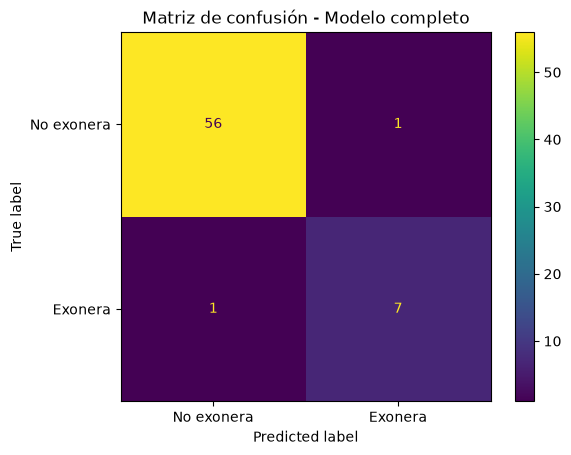

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_completo,
    display_labels=["No exonera", "Exonera"]
)

plt.title("Matriz de confusión - Modelo completo")
plt.show()

In [22]:
print(
    classification_report(
        y_test,
        y_pred_completo,
        target_names=["No exonera", "Exonera"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No exonera       0.98      0.98      0.98        57
     Exonera       0.88      0.88      0.88         8

    accuracy                           0.97        65
   macro avg       0.93      0.93      0.93        65
weighted avg       0.97      0.97      0.97        65



## 9. Comparación del rendimiento en entrenamiento y prueba

Para evaluar la posible presencia de sobreajuste, se comparan las métricas
obtenidas por cada modelo sobre los datos de entrenamiento y de prueba.

Una diferencia considerable entre ambos conjuntos podría indicar que el modelo
aprende patrones específicos de los datos de entrenamiento que no se generalizan
adecuadamente.

In [23]:
resultados_base_train, _, _ = evaluar_modelo(
    modelo_base,
    X_train_base,
    y_train
)

resultados_completo_train, _, _ = evaluar_modelo(
    modelo_completo,
    X_train_completo,
    y_train
)

In [24]:
comparacion_train_test = pd.DataFrame({
    "Base - Train": resultados_base_train,
    "Base - Test": resultados_base,
    "Completo - Train": resultados_completo_train,
    "Completo - Test": resultados_completo
}).T

comparacion_train_test.round(3)

,accuracy,precision,recall,f1,roc_auc
Base - Train,0.918,0.692,0.692,0.692,0.971
Base - Test,0.908,0.600,0.750,0.667,0.971
Completo - Train,0.969,0.955,0.808,0.875,0.984
Completo - Test,0.969,0.875,0.875,0.875,0.974


## 10. Validación cruzada estratificada

Debido al tamaño reducido del dataset y al desbalance de la variable objetivo,
un único conjunto de prueba puede producir métricas sensibles a la partición
realizada.

Por este motivo, se utiliza validación cruzada estratificada de 5 folds, manteniendo
aproximadamente la proporción de estudiantes que exoneran y no exoneran en cada
división.

Se evaluarán principalmente `F1-score` y `ROC-AUC`.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [26]:
cv_base = cross_validate(
    modelo_base,
    X_base,
    y,
    cv=cv,
    scoring=metricas
)

resultados_cv_base = pd.DataFrame({
    metrica: cv_base[f"test_{metrica}"]
    for metrica in metricas
})

resultados_cv_base

c:\Users\hugoc\miniconda3\envs\ml1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,accuracy,precision,recall,f1,roc_auc
0,0.884615,0.000000,0.000000,0.000000,0.978261
1,0.846154,0.444444,0.571429,0.500000,0.933333
2,0.923077,1.000000,0.428571,0.600000,0.984127
3,0.961538,1.000000,0.714286,0.833333,0.993651
4,0.923077,0.636364,1.000000,0.777778,0.992063


In [27]:
cv_completo = cross_validate(
    modelo_completo,
    X_completo,
    y,
    cv=cv,
    scoring=metricas
)

resultados_cv_completo = pd.DataFrame({
    metrica: cv_completo[f"test_{metrica}"]
    for metrica in metricas
})

resultados_cv_completo

,accuracy,precision,recall,f1,roc_auc
0,0.942308,1.000000,0.500000,0.666667,0.981884
1,0.923077,0.714286,0.714286,0.714286,0.977778
2,0.961538,1.000000,0.714286,0.833333,0.965079
3,0.980769,1.000000,0.857143,0.923077,0.996825
4,0.980769,0.875000,1.000000,0.933333,0.993651


In [28]:
resumen_cv = pd.DataFrame({
    "Modelo base - Media": resultados_cv_base.mean(),
    "Modelo base - Desv.": resultados_cv_base.std(),
    "Modelo completo - Media": resultados_cv_completo.mean(),
    "Modelo completo - Desv.": resultados_cv_completo.std()
}).T

resumen_cv.round(3)

,accuracy,precision,recall,f1,roc_auc
Modelo base - Media,0.908,0.616,0.543,0.542,0.976
Modelo base - Desv.,0.044,0.420,0.370,0.331,0.025
Modelo completo - Media,0.958,0.918,0.757,0.814,0.983
Modelo completo - Desv.,0.025,0.126,0.186,0.121,0.013


### Interpretación de la validación cruzada

La validación cruzada estratificada muestra que el modelo completo presenta un
rendimiento superior y más estable que el modelo base.

El modelo completo obtiene un F1-score promedio de aproximadamente 0.81 y un
ROC-AUC promedio de 0.98, con una variabilidad relativamente baja entre las
distintas particiones.

En cambio, el modelo basado únicamente en el primer parcial presenta una mayor
variabilidad. En una de las particiones no logró identificar ningún estudiante
que exonerara, lo que produjo valores de precisión, recall y F1 iguales a cero.

Estos resultados sugieren que incorporar información sobre el historial académico,
la carga de materias y la carrera aporta información adicional al puntaje del
primer parcial y mejora la estabilidad del modelo.

No se observa evidencia importante de sobreajuste, ya que el rendimiento se
mantiene consistente tanto en la división entrenamiento-prueba como en la
validación cruzada.

## 11. Interpretación de los coeficientes del modelo

La Regresión Logística permite analizar la dirección de la relación entre cada
variable y la probabilidad de alcanzar una firma de 71 puntos o más.

Un coeficiente positivo indica que, manteniendo constantes las demás variables,
un aumento en esa característica se asocia con una mayor probabilidad de exonerar.

Un coeficiente negativo indica una asociación con una menor probabilidad de
exonerar.

En las variables numéricas, los coeficientes corresponden a variables
estandarizadas. En la variable categórica `carrera`, los coeficientes representan
el efecto de cada categoría generada mediante One-Hot Encoding.

In [29]:
preprocesador_entrenado = modelo_completo.named_steps["preprocesamiento"]
modelo_logistico = modelo_completo.named_steps["modelo"]

nombres_features = preprocesador_entrenado.get_feature_names_out()

coeficientes = modelo_logistico.coef_[0]

coef_df = pd.DataFrame({
    "variable": nombres_features,
    "coeficiente": coeficientes
})

coef_df = coef_df.sort_values(
    "coeficiente",
    ascending=False
)

coef_df

,variable,coeficiente
0,num__primer_parcial,2.773097
4,num__tasa_aprobacion_anterior,0.864556
2,num__cantidad_materias_actual,0.544975
5,cat__carrera_Ing. Electromecánica,0.266003
3,num__cantidad_materias_anterior,0.195220
1,num__firma_previa,0.100524
8,cat__carrera_Ing. Industrial,-0.270740
7,cat__carrera_Ing. Geográfica,-0.284506
9,cat__carrera_Ing. Mecatrónica,-0.312629
10,cat__carrera_Ing. Mecánica,-0.376284


In [30]:
coef_df["variable"] = (
    coef_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df

,variable,coeficiente
0,primer_parcial,2.773097
4,tasa_aprobacion_anterior,0.864556
2,cantidad_materias_actual,0.544975
5,carrera_Ing. Electromecánica,0.266003
3,cantidad_materias_anterior,0.195220
1,firma_previa,0.100524
8,carrera_Ing. Industrial,-0.270740
7,carrera_Ing. Geográfica,-0.284506
9,carrera_Ing. Mecatrónica,-0.312629
10,carrera_Ing. Mecánica,-0.376284


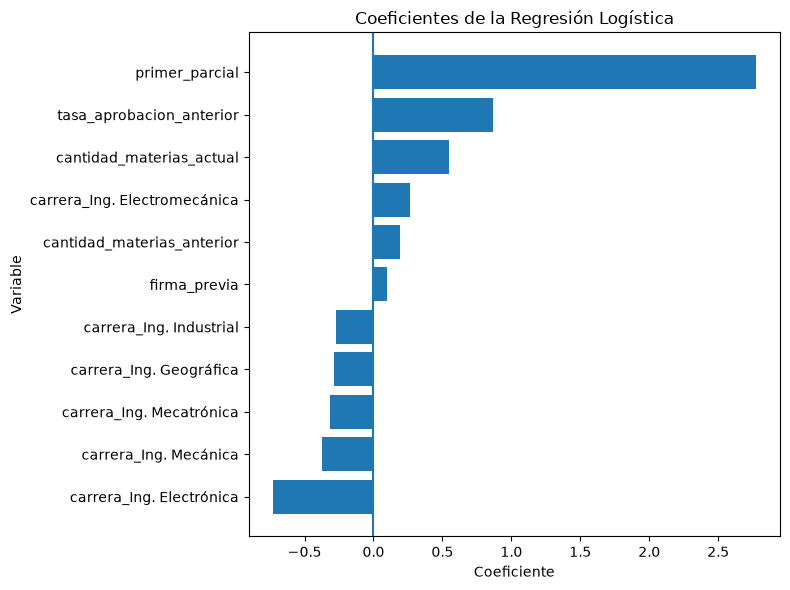

In [31]:
coef_plot = coef_df.sort_values("coeficiente")

plt.figure(figsize=(8, 6))

plt.barh(
    coef_plot["variable"],
    coef_plot["coeficiente"]
)

plt.axvline(0)

plt.title("Coeficientes de la Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [32]:
coef_df["odds_ratio"] = np.exp(coef_df["coeficiente"])

coef_df.sort_values(
    "odds_ratio",
    ascending=False
)

,variable,coeficiente,odds_ratio
0,primer_parcial,2.773097,16.008137
4,tasa_aprobacion_anterior,0.864556,2.373952
2,cantidad_materias_actual,0.544975,1.724565
5,carrera_Ing. Electromecánica,0.266003,1.304739
3,cantidad_materias_anterior,0.195220,1.215578
1,firma_previa,0.100524,1.105750
8,carrera_Ing. Industrial,-0.270740,0.762815
7,carrera_Ing. Geográfica,-0.284506,0.752386
9,carrera_Ing. Mecatrónica,-0.312629,0.731521
10,carrera_Ing. Mecánica,-0.376284,0.686407


### Interpretación de los coeficientes

El `primer_parcial` es la variable con mayor peso en el modelo. Su coeficiente
es positivo y considerablemente mayor que el del resto de las variables,
indicando una fuerte asociación entre un mejor rendimiento en esta evaluación
y la posibilidad de alcanzar una firma de 71 puntos o más.

Debido a que las variables numéricas fueron estandarizadas, sus odds ratios
representan el cambio asociado a un aumento de una desviación estándar en la
variable. En el caso del `primer_parcial`, su odds ratio es aproximadamente 16,
lo que confirma que constituye el principal factor predictivo dentro del modelo.

La `tasa_aprobacion_anterior` también presenta una asociación positiva relevante,
con un odds ratio aproximado de 2.37. Esto sugiere que un mejor rendimiento
académico en el ciclo anterior aporta información adicional para estimar la
posibilidad de exonerar.

La `cantidad_materias_actual` y la `cantidad_materias_anterior` presentan
coeficientes positivos. En esta cohorte, una mayor carga académica no aparece
asociada necesariamente con una menor posibilidad de exonerar. Sin embargo,
este resultado debe interpretarse como una asociación y no como una relación
causal.

La `firma_previa` presenta un coeficiente pequeño y un odds ratio cercano a 1,
por lo que aporta relativamente poca información adicional una vez consideradas
las demás características del estudiante.

Para la variable `carrera`, Ingeniería Civil funciona como categoría de referencia.
Por lo tanto, los coeficientes de las demás carreras representan diferencias
respecto a Ingeniería Civil, manteniendo constantes las demás variables.

Ingeniería Electromecánica presenta un coeficiente ligeramente positivo respecto
a Ingeniería Civil, mientras que las demás carreras presentan coeficientes
negativos. Estas diferencias deben interpretarse con precaución debido al tamaño
reducido y desigual de las muestras por carrera, especialmente en algunas
categorías.

En conjunto, los resultados indican que el primer parcial es el factor que más
contribuye a anticipar la posibilidad de alcanzar una firma de 71 puntos o más,
mientras que el rendimiento académico previo y otras características aportan
información adicional que mejora el desempeño y la estabilidad del modelo.

## 12. Conclusiones del modelado

La Regresión Logística permitió estimar la posibilidad de que un estudiante de
Métodos Numéricos alcance una firma de 71 puntos o más utilizando información
disponible después del primer parcial.

El modelo completo mostró un mejor rendimiento que el modelo que utiliza
únicamente el primer parcial. En la validación cruzada estratificada obtuvo un
F1-score promedio cercano a 0.81 y un ROC-AUC aproximado de 0.98, además de una
menor variabilidad entre particiones.

El primer parcial resultó ser el predictor más importante. Sin embargo, el
rendimiento académico del ciclo anterior, particularmente la tasa de aprobación,
aportó información adicional y permitió obtener un modelo más estable.

La firma previa mostró una contribución reducida una vez incorporadas las demás
variables. La carga académica presentó una asociación positiva en esta cohorte,
aunque este resultado no debe interpretarse de manera causal.

Por lo tanto, los resultados sugieren que el desempeño alcanzado en el primer
parcial, complementado con información sobre el rendimiento académico previo,
permite estimar de manera útil qué estudiantes tienen mayor posibilidad de
alcanzar el puntaje necesario para exonerar.

Los resultados deben interpretarse considerando las limitaciones del análisis:
el dataset contiene solamente 260 estudiantes, de los cuales 34 alcanzaron el
umbral de 71 puntos, y algunas carreras poseen pocos casos. Por este motivo,
sería conveniente validar el modelo con datos de otros períodos académicos antes
de utilizarlo para realizar predicciones sobre nuevas cohortes.